In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets import mnist
import cv2
from scipy import ndimage
import albumentations as A
import random
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load a sample dataset - we'll use both a tabular dataset and an image dataset
# For tabular data, let's use the Titanic dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Basic Exploration
print(f"Dataset shape: {df.shape}")
print("\nMissing values per column:")
print(df.isnull().sum())

Dataset shape: (891, 12)

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
# Fill missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Cabin'].fillna('Unknown', inplace=True)

# ----- FEATURE ENGINEERING FOR TABULAR DATA -----

In [5]:
# 1. Extract title from name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# Group rare titles
rare_titles = ['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

In [6]:
# 2. Create family size feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger themselves

In [7]:
# 3. Create is_alone feature
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

In [8]:
# 4. Create fare per person
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

In [9]:
# 5. Bin age into categories
df['AgeBin'] = pd.cut(df['Age'], bins=[0, 12, 18, 65, 100], labels=['Child', 'Teenager', 'Adult', 'Elderly'])

In [11]:
# 6. Bin fare into categories
df['FareBin'] = pd.qcut(df['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])

In [12]:
# 7. Create deck from cabin
df['Deck'] = df['Cabin'].str[0]
df['Deck'] = df['Deck'].replace(['T', 'A', 'G'], 'Other')
df['Deck'] = df['Deck'].replace('Unknown', 'U')


In [13]:
# 8. Interaction features
df['Family_Survival'] = df['FamilySize'] * df['Survived']

In [14]:
# 9. Categorical encodings
# One-hot encoding for categorical features
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'AgeBin', 'FareBin', 'Deck']
df_encoded = pd.get_dummies(df[categorical_features], drop_first=True)

In [15]:
# Combine with numerical features
numerical_features = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson']
X = pd.concat([df[numerical_features], df_encoded], axis=1)
y = df['Survived']

In [16]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
# Feature selection using SelectKBest
selector = SelectKBest(f_classif, k=15)
X_selected = selector.fit_transform(X_scaled, y)

In [18]:
# Display top features
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
})
top_features = feature_scores.sort_values('Score', ascending=False).head(15)
print("\nTop 15 features:")
print(top_features)


Top 15 features:
              Feature       Score
12           Title_Mr  383.945495
8            Sex_male  372.405724
13          Title_Mrs  117.749079
7              Pclass  115.031272
11         Title_Miss  112.860827
26             Deck_U   99.253142
3                Fare   63.030764
20  FareBin_Very High   51.329338
6       FarePerPerson   45.910184
5             IsAlone   38.353651
22             Deck_D   20.663186
10         Embarked_S   20.374460
23             Deck_E   19.179221
21             Deck_C   11.841661
18     FareBin_Medium    8.208162


In [19]:
# Train a model with the engineered features
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.25, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [20]:
# Evaluate the model
y_pred = model.predict(X_test)
print("\nModel accuracy with engineered features:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))


Model accuracy with engineered features: 0.8116591928251121

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       134
           1       0.76      0.78      0.77        89

    accuracy                           0.81       223
   macro avg       0.80      0.81      0.80       223
weighted avg       0.81      0.81      0.81       223



# ----- ADVANCED FEATURE ENGINEERING -----

In [21]:
# 1. Polynomial features (example with a simple subset)
from sklearn.preprocessing import PolynomialFeatures

In [22]:
# Just using Age and Fare for demonstration
poly_features = PolynomialFeatures(degree=2, include_bias=False)
poly_data = poly_features.fit_transform(df[['Age', 'Fare']].fillna(0))

In [23]:
# Display polynomial feature names
feature_names = poly_features.get_feature_names_out(['Age', 'Fare'])
print("\nPolynomial features generated:")
print(feature_names)


Polynomial features generated:
['Age' 'Fare' 'Age^2' 'Age Fare' 'Fare^2']


In [24]:
# 2. PCA for dimensionality reduction
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

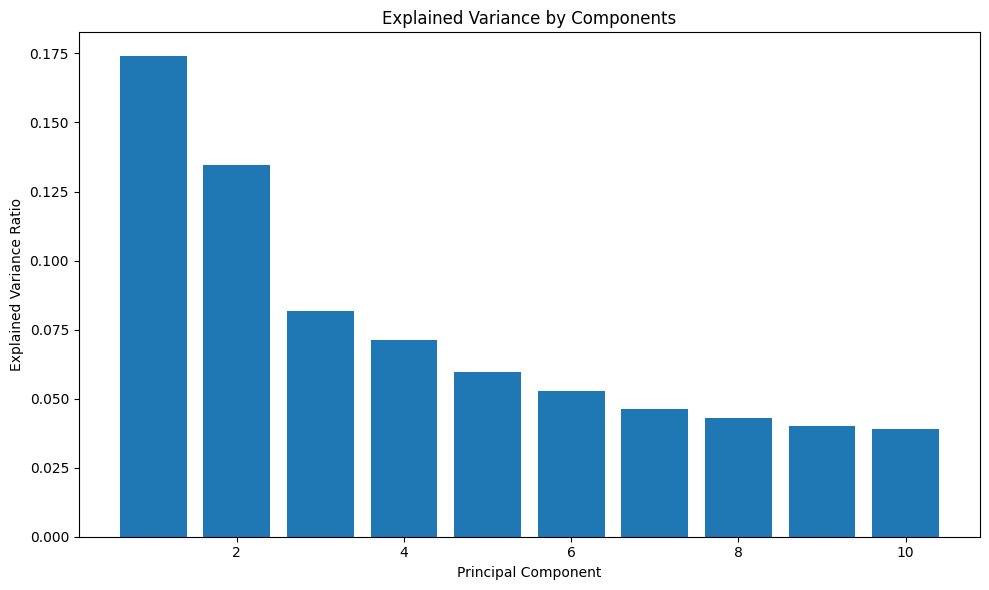

In [25]:
# Plot explained variance ratio
plt.figure(figsize=(10, 6))
plt.bar(range(1, 11), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Components')
plt.tight_layout()
plt.show()

In [26]:
# Print cumulative explained variance
print("\nCumulative explained variance:")
print(np.cumsum(pca.explained_variance_ratio_))


Cumulative explained variance:
[0.17394189 0.30865766 0.39044823 0.46166279 0.52117907 0.57399528
 0.62017507 0.66317021 0.70334202 0.74223912]


# ----- DATA AUGMENTATION FOR IMAGES -----

In [27]:
# Load MNIST dataset for image augmentation examples
(X_train_img, y_train_img), (X_test_img, y_test_img) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [30]:
# Normalize the data
X_train_img = X_train_img / 255.0
X_test_img = X_test_img / 255.0

In [31]:
# Expand dimensions for Keras (add channel dimension)
X_train_img = X_train_img.reshape(-1, 28, 28, 1)
X_test_img = X_test_img.reshape(-1, 28, 28, 1)

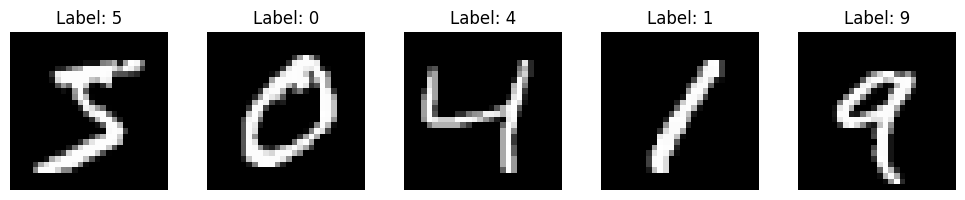

In [32]:
# Display some original images
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train_img[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.title(f"Label: {y_train_img[i]}")
plt.tight_layout()
plt.show()


In [56]:
# ----- 1. BASIC IMAGE AUGMENTATION WITH KERAS -----

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    # brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    fill_mode='nearest'
)

In [57]:
# Visualize augmented images
augmented_images = []
for x_batch in datagen.flow(X_train_img[:5], batch_size=1, shuffle=False):
    augmented_images.append(x_batch[0])
    if len(augmented_images) >= 15:  # Generate 3 augmented versions of each of the 5 images
        break

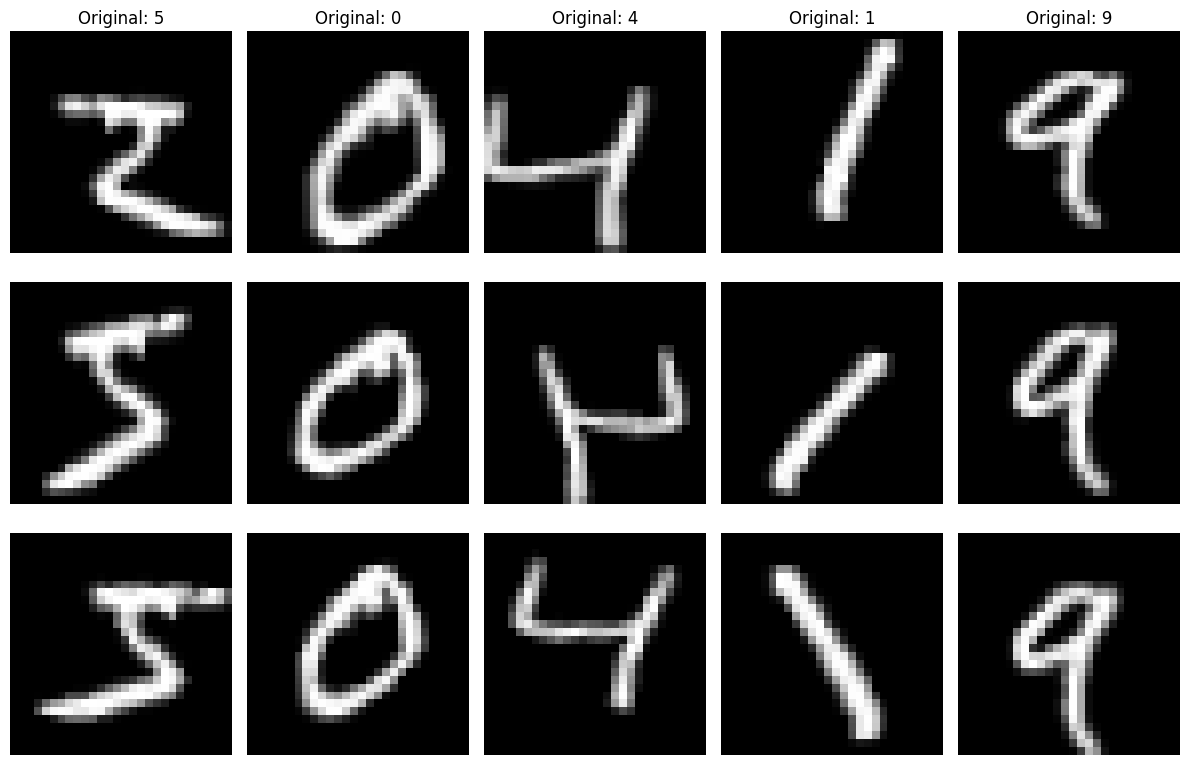

In [58]:
# Display augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(augmented_images):
    plt.subplot(3, 5, i+1)
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i < 5:
        plt.title(f"Original: {y_train_img[i]}")
plt.tight_layout()
plt.show()

In [59]:
# ----- 2. AUGMENTATION WITH TF.IMAGE -----
def augment_with_tf(image):
    # Convert to float32
    image = tf.cast(image, tf.float32)

    # Random rotation
    image = tf.image.rot90(image, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))

    # Random brightness
    image = tf.image.random_brightness(image, max_delta=0.2)

    # Random contrast
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

    # Ensure values are still between 0 and 1
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image

In [60]:
# Apply tf.image augmentation to a few images
augmented_tf_images = []
for i in range(5):
    # Create 3 augmented versions of each image
    for _ in range(3):
        aug_img = augment_with_tf(X_train_img[i]).numpy()
        augmented_tf_images.append(aug_img)

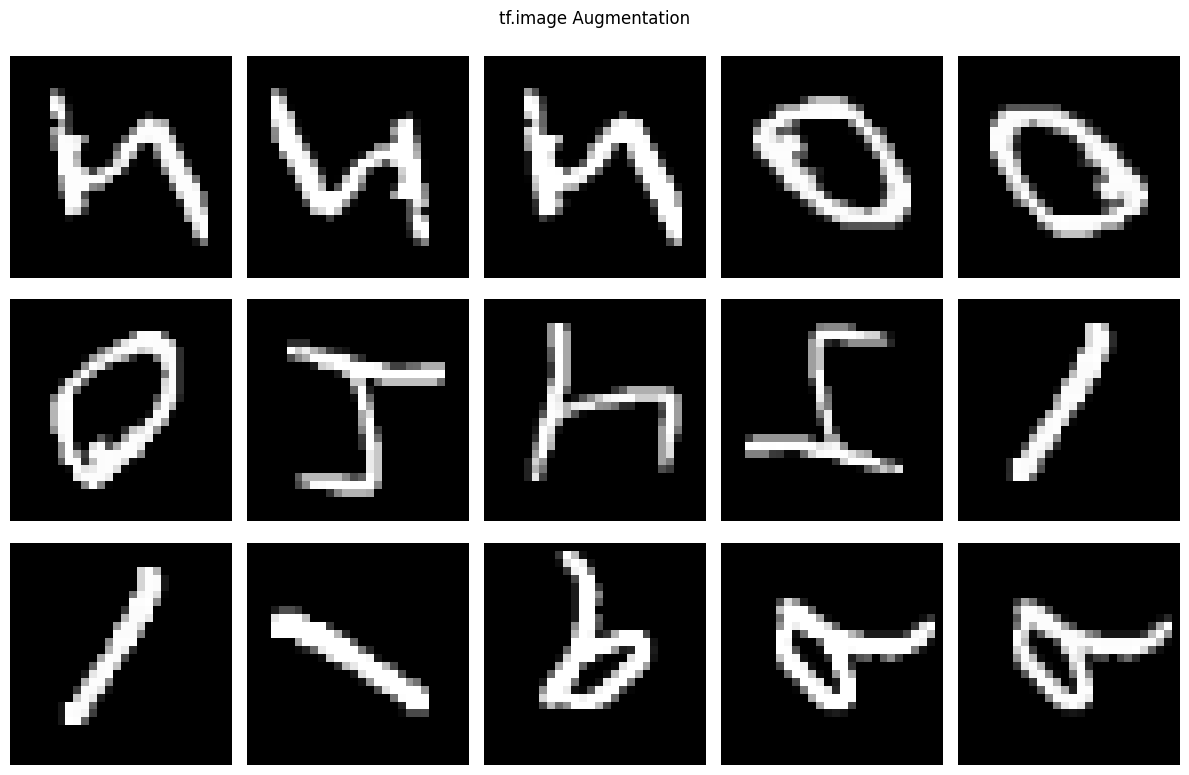

In [61]:
# Display tf.image augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(augmented_tf_images):
    plt.subplot(3, 5, i+1)
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle('tf.image Augmentation')
plt.tight_layout()
plt.show()

In [62]:
# ----- 3. AUGMENTATION WITH OPENCV -----

def opencv_augment(image):
    # Convert to 0-255 range and uint8 for OpenCV
    image = (image * 255).astype(np.uint8).reshape(28, 28)

    # Choose a random augmentation
    choice = np.random.choice(['rotate', 'blur', 'zoom', 'original'])

    if choice == 'rotate':
        # Random rotation
        angle = np.random.uniform(-15, 15)
        return ndimage.rotate(image, angle, reshape=False)

    elif choice == 'blur':
        # Add blur
        return cv2.GaussianBlur(image, (3, 3), 0)

    elif choice == 'zoom':
        # Random zoom
        zoom_factor = np.random.uniform(0.8, 1.2)
        height, width = image.shape

        # Compute new dimensions
        new_height = int(height * zoom_factor)
        new_width = int(width * zoom_factor)

        if zoom_factor < 1:  # Zoom out
            # Crop the image
            y_start = (height - new_height) // 2
            x_start = (width - new_width) // 2
            cropped = image[y_start:y_start+new_height, x_start:x_start+new_width]
            # Resize back to original size
            return cv2.resize(cropped, (width, height))
        else:  # Zoom in
            # Resize
            resized = cv2.resize(image, (new_width, new_height))
            # Crop to original size
            y_start = (new_height - height) // 2
            x_start = (new_width - width) // 2
            return resized[y_start:y_start+height, x_start:x_start+width]

    else:
        # Return original
        return image

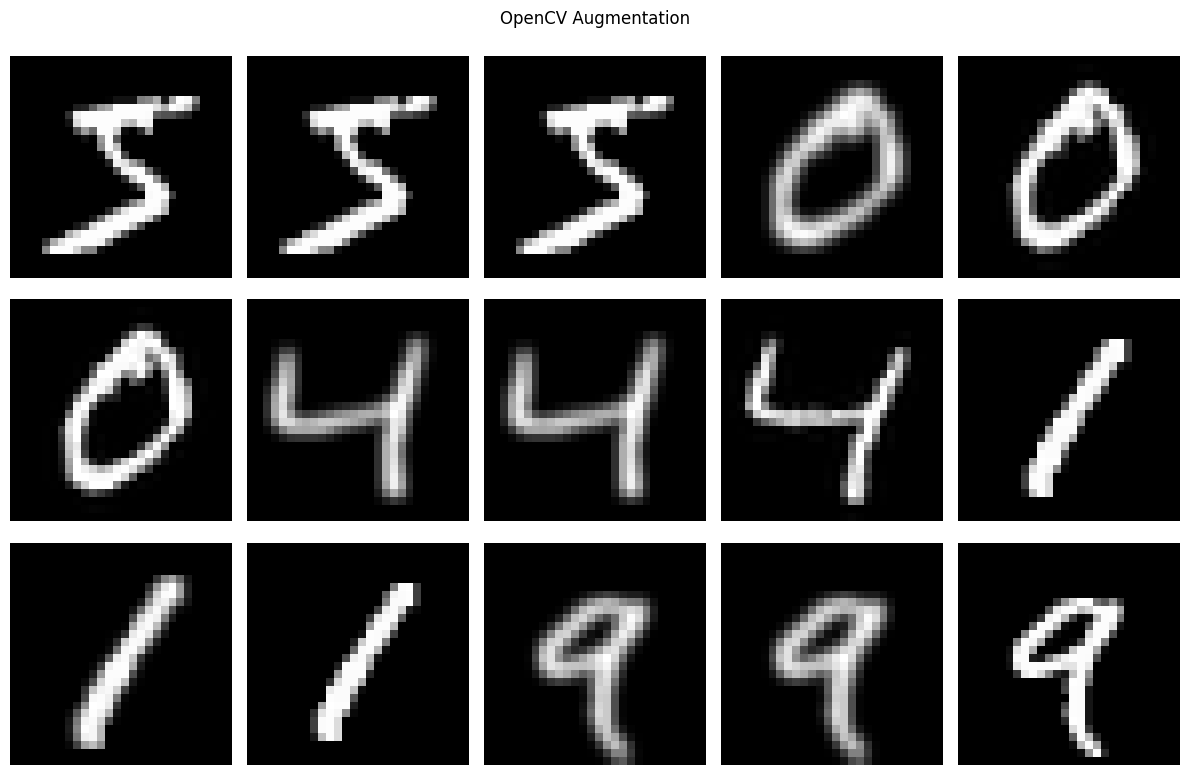

In [63]:

# Apply OpenCV augmentation
opencv_augmented = []
for i in range(5):
    # Create 3 augmented versions of each image
    for _ in range(3):
        aug_img = opencv_augment(X_train_img[i])
        # Normalize back to 0-1
        aug_img = aug_img.astype(np.float32) / 255.0
        opencv_augmented.append(aug_img)

# Display OpenCV augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(opencv_augmented):
    plt.subplot(3, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle('OpenCV Augmentation')
plt.tight_layout()
plt.show()

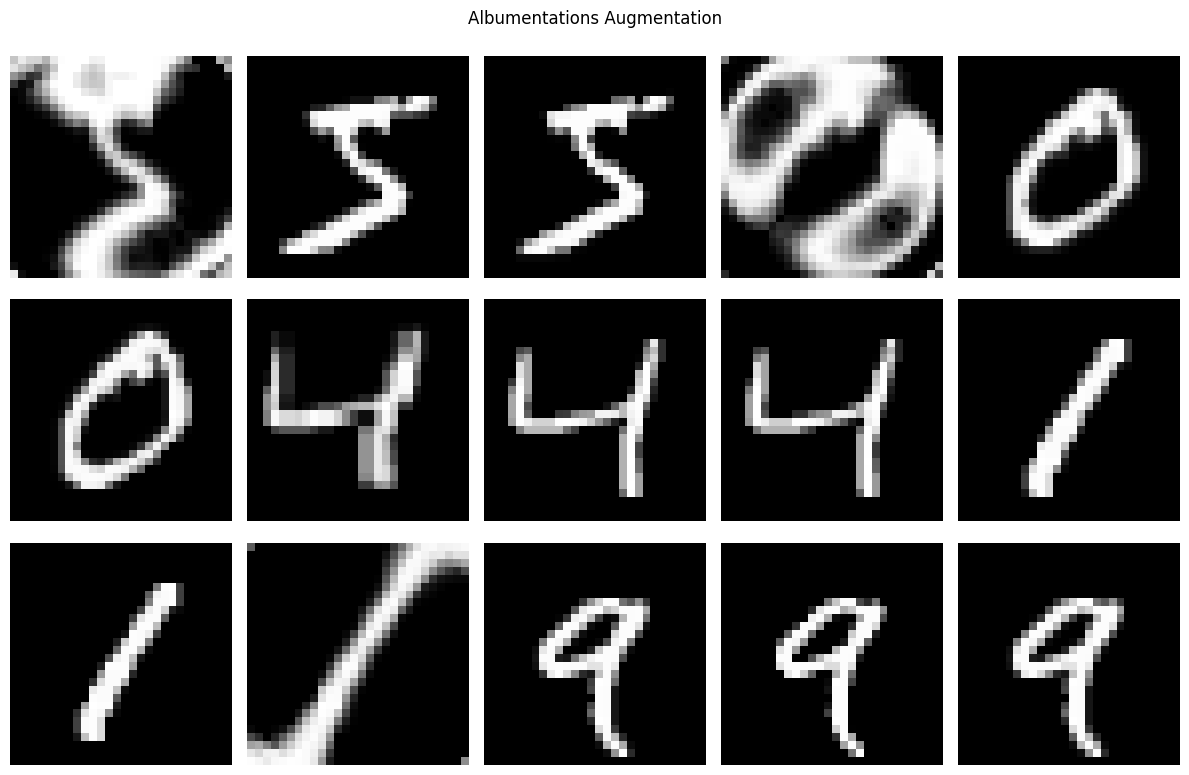

In [64]:
# ----- 4. AUGMENTATION WITH ALBUMENTATIONS -----

def apply_albumentation(image):
    # Convert to 0-255 range and uint8 for Albumentations
    image = (image * 255).astype(np.uint8).reshape(28, 28)

    # Define transformation pipeline
    transform = A.Compose([
        A.OneOf([
            A.RandomBrightnessContrast(p=0.8),
            A.RandomGamma(p=0.8),
        ], p=0.5),
        A.OneOf([
            A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.5),
            A.GridDistortion(p=0.5),
            A.OpticalDistortion(distort_limit=2, shift_limit=0.5, p=0.5),
        ], p=0.5),
    ])

    # Apply transformation
    augmented = transform(image=image)['image']

    # Normalize back to 0-1
    return augmented.astype(np.float32) / 255.0

# Apply Albumentations
albu_augmented = []
for i in range(5):
    # Create 3 augmented versions of each image
    for _ in range(3):
        aug_img = apply_albumentation(X_train_img[i])
        albu_augmented.append(aug_img)

# Display Albumentations augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(albu_augmented):
    plt.subplot(3, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle('Albumentations Augmentation')
plt.tight_layout()
plt.show()


In [65]:
# ----- 5. TEXT DATA AUGMENTATION -----

# Sample texts
texts = [
    "This is a great product, I love it!",
    "The service was terrible and I'm disappointed.",
    "I'm not sure how I feel about this experience.",
    "The food was delicious and the staff was friendly.",
    "This movie is boring and too long."
]

In [66]:
# Simple text augmentation techniques
def swap_words(text):
    words = text.split()
    if len(words) <= 1:
        return text

    idx1, idx2 = sorted(random.sample(range(len(words)), 2))
    words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

def delete_random_word(text):
    words = text.split()
    if len(words) <= 1:
        return text

    idx = random.randrange(len(words))
    return ' '.join(words[:idx] + words[idx+1:])

def insert_random_word(text, word_list=["really", "very", "somewhat", "quite", "extremely"]):
    words = text.split()
    if not words:
        return text

    idx = random.randrange(len(words))
    word_to_insert = random.choice(word_list)
    return ' '.join(words[:idx] + [word_to_insert] + words[idx:])

In [67]:
# Apply text augmentation
augmented_texts = []
for text in texts:
    augmented_texts.append(("Original", text))
    augmented_texts.append(("Word Swap", swap_words(text)))
    augmented_texts.append(("Word Deletion", delete_random_word(text)))
    augmented_texts.append(("Word Insertion", insert_random_word(text)))

In [68]:
# Display original and augmented texts
print("\nText Data Augmentation Examples:")
for aug_type, text in augmented_texts:
    print(f"{aug_type}: {text}")


Text Data Augmentation Examples:
Original: This is a great product, I love it!
Word Swap: This is a it! product, I love great
Word Deletion: This is great product, I love it!
Word Insertion: This quite is a great product, I love it!
Original: The service was terrible and I'm disappointed.
Word Swap: service The was terrible and I'm disappointed.
Word Deletion: The service was terrible and I'm
Word Insertion: The service was quite terrible and I'm disappointed.
Original: I'm not sure how I feel about this experience.
Word Swap: feel not sure how I I'm about this experience.
Word Deletion: I'm not sure how feel about this experience.
Word Insertion: I'm not sure how I feel about extremely this experience.
Original: The food was delicious and the staff was friendly.
Word Swap: The food was staff and the delicious was friendly.
Word Deletion: The food was and the staff was friendly.
Word Insertion: The food was delicious and the extremely staff was friendly.
Original: This movie is boring

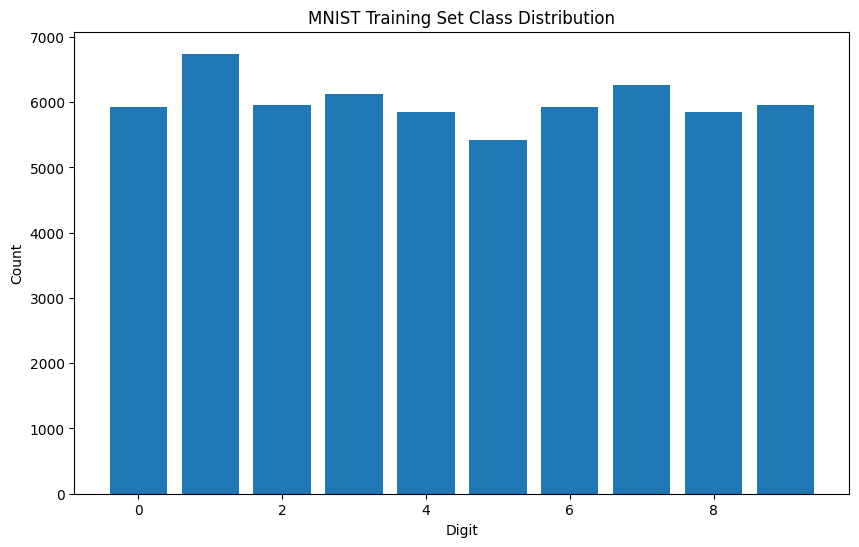

In [69]:
# ----- 6. ADVANCED APPLICATION: AUGMENT TO BALANCE CLASSES -----

# Check distribution of classes in MNIST
unique, counts = np.unique(y_train_img, return_counts=True)
class_distribution = dict(zip(unique, counts))

plt.figure(figsize=(10, 6))
plt.bar(class_distribution.keys(), class_distribution.values())
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('MNIST Training Set Class Distribution')
plt.show()

In [70]:

def augment_minority_class(X, y, target_class, num_samples):
    # Find samples of the target class
    class_indices = np.where(y == target_class)[0]
    X_class = X[class_indices]

    # If we already have enough samples, no need to augment
    if len(X_class) >= num_samples:
        return X, y

    # Number of augmentations needed
    num_augmentations = num_samples - len(X_class)

    # Create augmentation generator
    datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Generate augmented images
    augmented_images = []
    augmented_labels = []

    for x_batch in datagen.flow(X_class, batch_size=1, shuffle=True):
        augmented_images.append(x_batch[0])
        augmented_labels.append(target_class)
        if len(augmented_images) >= num_augmentations:
            break

    # Convert to numpy arrays
    augmented_images = np.array(augmented_images)
    augmented_labels = np.array(augmented_labels)

    # Combine original and augmented data
    X_balanced = np.vstack([X, augmented_images])
    y_balanced = np.hstack([y, augmented_labels])

    return X_balanced, y_balanced

In [71]:
# Demonstrate balancing a subset of MNIST
# For demonstration, let's use just 100 samples per class initially
X_sample = []
y_sample = []

for digit in range(10):
    indices = np.where(y_train_img == digit)[0][:100]  # Take 100 samples of each digit
    X_sample.extend(X_train_img[indices])
    y_sample.extend(y_train_img[indices])

X_sample = np.array(X_sample)
y_sample = np.array(y_sample)

In [72]:
# Print initial distribution
unique, counts = np.unique(y_sample, return_counts=True)
print("\nInitial distribution:")
print(dict(zip(unique, counts)))


Initial distribution:
{np.uint8(0): np.int64(100), np.uint8(1): np.int64(100), np.uint8(2): np.int64(100), np.uint8(3): np.int64(100), np.uint8(4): np.int64(100), np.uint8(5): np.int64(100), np.uint8(6): np.int64(100), np.uint8(7): np.int64(100), np.uint8(8): np.int64(100), np.uint8(9): np.int64(100)}


In [73]:
# Let's artificially create an imbalance by removing some '8' samples
eight_indices = np.where(y_sample == 8)[0]
remove_indices = eight_indices[:80]  # Remove 80 samples of digit 8
mask = np.ones(len(y_sample), dtype=bool)
mask[remove_indices] = False

X_imbalanced = X_sample[mask]
y_imbalanced = y_sample[mask]


In [74]:
# Print imbalanced distribution
unique, counts = np.unique(y_imbalanced, return_counts=True)
print("\nImbalanced distribution:")
print(dict(zip(unique, counts)))



Imbalanced distribution:
{np.uint8(0): np.int64(100), np.uint8(1): np.int64(100), np.uint8(2): np.int64(100), np.uint8(3): np.int64(100), np.uint8(4): np.int64(100), np.uint8(5): np.int64(100), np.uint8(6): np.int64(100), np.uint8(7): np.int64(100), np.uint8(8): np.int64(20), np.uint8(9): np.int64(100)}


In [75]:
# Balance the dataset using augmentation
X_balanced, y_balanced = augment_minority_class(X_imbalanced, y_imbalanced, 8, 100)

# Print balanced distribution
unique, counts = np.unique(y_balanced, return_counts=True)
print("\nBalanced distribution after augmentation:")
print(dict(zip(unique, counts)))


Balanced distribution after augmentation:
{np.int64(0): np.int64(100), np.int64(1): np.int64(100), np.int64(2): np.int64(100), np.int64(3): np.int64(100), np.int64(4): np.int64(100), np.int64(5): np.int64(100), np.int64(6): np.int64(100), np.int64(7): np.int64(100), np.int64(8): np.int64(100), np.int64(9): np.int64(100)}


In [76]:
# ----- 7. DEMONSTRATING THE EFFECT OF AUGMENTATION ON MODEL PERFORMANCE -----

# Create a simple CNN model for MNIST
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [77]:
# Train model on imbalanced data
model_imbalanced = create_model()
history_imbalanced = model_imbalanced.fit(X_imbalanced, y_imbalanced, epochs=5,
                                           validation_split=0.2, verbose=0)


In [78]:
# Train model on balanced data
model_balanced = create_model()
history_balanced = model_balanced.fit(X_balanced, y_balanced, epochs=5,
                                       validation_split=0.2, verbose=0)

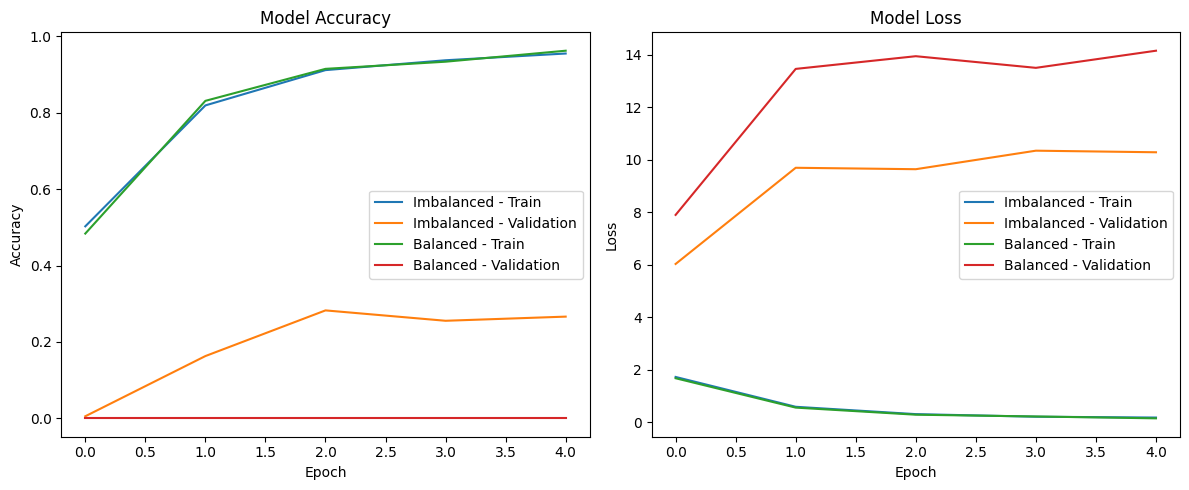

In [79]:
# Compare performance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_imbalanced.history['accuracy'], label='Imbalanced - Train')
plt.plot(history_imbalanced.history['val_accuracy'], label='Imbalanced - Validation')
plt.plot(history_balanced.history['accuracy'], label='Balanced - Train')
plt.plot(history_balanced.history['val_accuracy'], label='Balanced - Validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_imbalanced.history['loss'], label='Imbalanced - Train')
plt.plot(history_imbalanced.history['val_loss'], label='Imbalanced - Validation')
plt.plot(history_balanced.history['loss'], label='Balanced - Train')
plt.plot(history_balanced.history['val_loss'], label='Balanced - Validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

## Exercise

In [80]:
# 1. Setup and Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Load the Titanic dataset into `df` using pd.read_csv
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Display first 5 rows and the dataset shape
print(df.head())
print(f"\nDataset shape: {df.shape}")

# Print missing value counts per column
print("\nMissing values per column:")
print(df.isnull().sum())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  

D

In [81]:
# Fill missing 'Age' with its median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing 'Embarked' with its mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Replace missing 'Cabin' entries with 'Unknown'
df['Cabin'] = df['Cabin'].fillna('Unknown')

In [82]:
# 3.1 Extract Title from Name
df['Title'] = df['Name'].str.extract(r',\s*([^\.]*)\s*\.')

# 3.2 Group rare titles into 'Rare' and standardize variants
# First, standardize common variants/misspellings
df['Title'] = df['Title'].replace({
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
})

# Define rare titles (low frequency ones)
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
               'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']

# Replace rare titles with 'Rare'
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

# 3.3 Family Size and IsAlone
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = np.where(df['FamilySize'] == 1, 1, 0)

# 3.4 Fare Per Person
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

# 3.5 Age and Fare Binning
df['AgeBin'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 65, np.inf],
    labels=['Child', 'Teenager', 'Adult', 'Elderly']
)

df['FareBin'] = pd.qcut(
    df['Fare'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

# 3.6 Deck from Cabin
df['Deck'] = df['Cabin'].str[0]
df['Deck'] = df['Deck'].replace('U', 'U')  # 'Unknown' was already filled earlier, first letter is 'U'
df['Deck'] = df['Deck'].fillna('U')

# Replace rare deck letters with 'Other' (keep common ones, e.g., top 4-5 decks)
deck_counts = df['Deck'].value_counts()
rare_decks = deck_counts[deck_counts < 10].index  # threshold: fewer than 10 occurrences
df['Deck'] = df['Deck'].replace(rare_decks, 'Other')

In [83]:
# 4.1 One-hot encode selected categorical columns using pd.get_dummies
categorical = ['Pclass', 'Sex', 'Embarked', 'Title', 'AgeBin', 'FareBin', 'Deck']
df_encoded = pd.get_dummies(df[categorical], drop_first=True)

# 4.2 Combine with numerical features
numerical = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson']
X = pd.concat([df[numerical], df_encoded], axis=1)
y = df['Survived']

# 4.3 Feature scaling: fit three different scalers and transform X
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()
scaler_rbv = RobustScaler()

X_std = scaler_std.fit_transform(X)
X_mm = scaler_mm.fit_transform(X)
X_rb = scaler_rbv.fit_transform(X)

In [84]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Use SelectKBest(f_classif, k=15) to pick top features
selector = SelectKBest(f_classif, k=15)
X_sel = selector.fit_transform(X_std, y)

top_feats = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).nlargest(15, 'Score')

print("Top 15 Features:")
print(top_feats)

# Split into train/test (25% test), train RandomForestClassifier, and print results
X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=0.25, random_state=42
)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Top 15 Features:
              Feature       Score
12           Title_Mr  383.945495
8            Sex_male  372.405724
13          Title_Mrs  117.749079
7              Pclass  115.031272
11         Title_Miss  112.860827
28             Deck_U   99.253142
3                Fare   63.030764
21  FareBin_Very High   51.329338
6       FarePerPerson   45.910184
5             IsAlone   38.353651
22             Deck_B   28.117228
24             Deck_D   20.663186
10         Embarked_S   20.374460
25             Deck_E   19.179221
23             Deck_C   11.841661

Accuracy: 0.8072

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.84       134
           1       0.74      0.80      0.77        89

    accuracy                           0.81       223
   macro avg       0.80      0.81      0.80       223
weighted avg       0.81      0.81      0.81       223



['Age' 'Fare' 'Age^2' 'Age Fare' 'Fare^2']


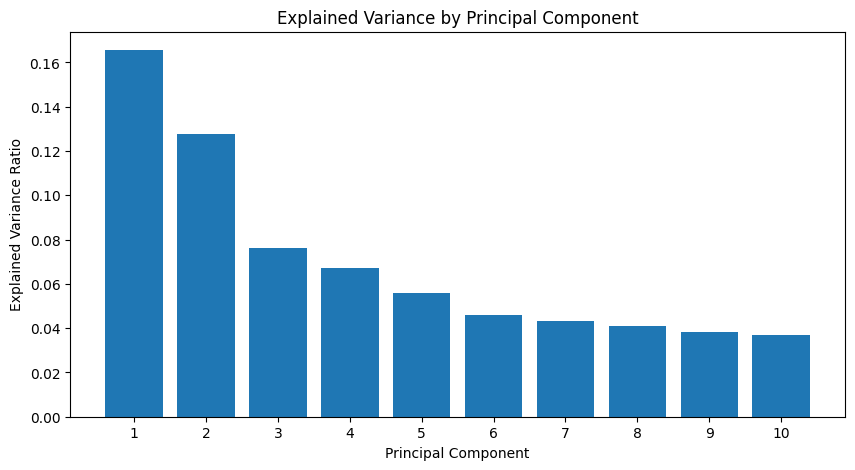

Cumulative Explained Variance:
[0.16557642 0.29319813 0.36952882 0.43657577 0.49244873 0.53829101
 0.58152354 0.62254601 0.66099613 0.69775844]


In [85]:
# 6.1 Polynomial Features using sklearn.preprocessing.PolynomialFeatures
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_data = poly.fit_transform(df[['Age', 'Fare']].fillna(0))
print(poly.get_feature_names_out(['Age', 'Fare']))

# 6.2 PCA for dimensionality reduction
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_std)

# Plot explained variance ratio bar chart
plt.figure(figsize=(10, 5))
plt.bar(range(1, 11), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Component')
plt.xticks(range(1, 11))
plt.show()

# Print cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print("Cumulative Explained Variance:")
print(cumulative_variance)

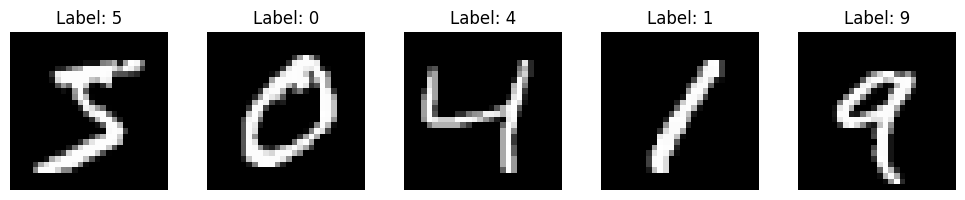

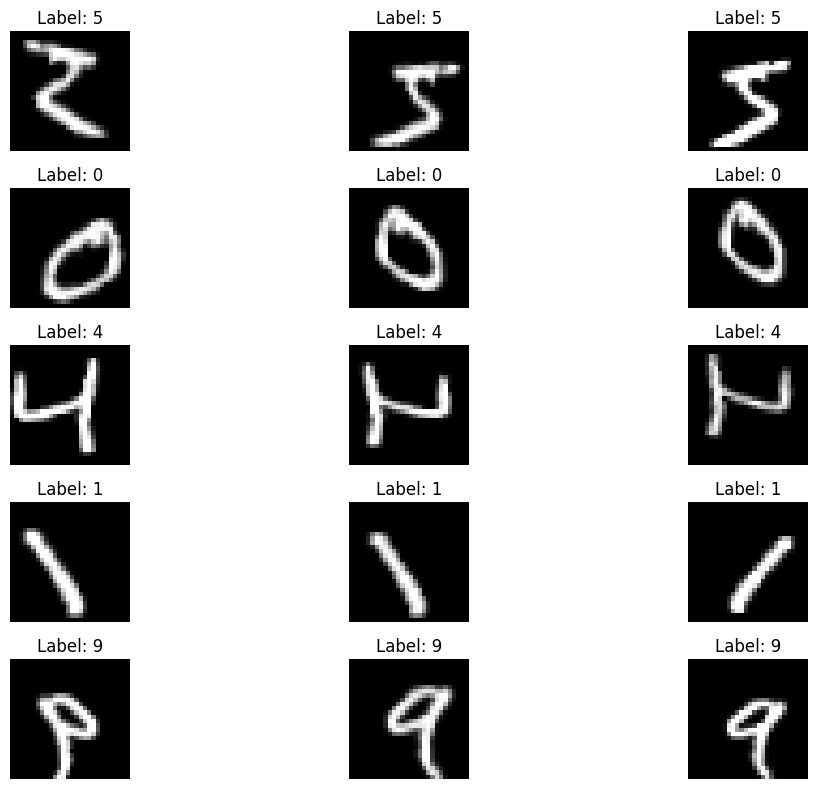

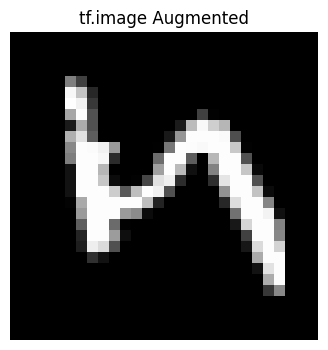

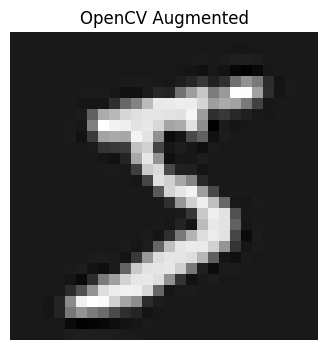

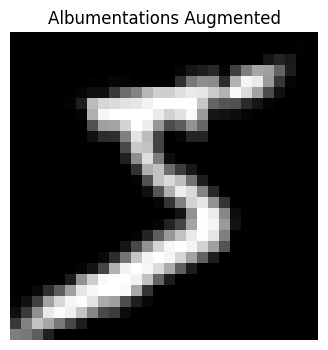

In [86]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets import mnist

# Load MNIST, normalize, and reshape to (28,28,1)
(X_train_img, y_train_img), (X_test_img, y_test_img) = mnist.load_data()
X_train_img = X_train_img.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test_img = X_test_img.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# Display 5 sample images with true labels
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train_img[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.title(f"Label: {y_train_img[i]}")
plt.tight_layout()
plt.show()

# 7.1 Keras ImageDataGenerator
datagen = ImageDataGenerator(rotation_range=10,
                             width_shift_range=0.1,
                             height_shift_range=0.1,
                             zoom_range=0.1,
                             shear_range=0.1,
                             brightness_range=[0.5,1.5],
                             horizontal_flip=True,
                             fill_mode='nearest')

# Generate and plot 3 augmentations per sample for first 5 images
# NOTE: brightness_range needs 0-255 scale internally, so we temporarily rescale up, then back down
plt.figure(figsize=(12, 8))
plot_idx = 1
for i in range(5):
    img = X_train_img[i:i+1] * 255.0  # rescale to 0-255 for correct brightness handling
    count = 0
    for x_batch in datagen.flow(img, batch_size=1, shuffle=False):
        aug_img = x_batch[0] / 255.0  # rescale back to 0-1 for display
        plt.subplot(5, 3, plot_idx)
        plt.imshow(aug_img.reshape(28, 28), cmap='gray')
        plt.axis('off')
        plt.title(f"Label: {y_train_img[i]}")
        plot_idx += 1
        count += 1
        if count >= 3:
            break
plt.tight_layout()
plt.show()

# 7.2 tf.image augmentations
import tensorflow as tf

def tf_augment(image):
    image = tf.image.rot90(image, k=1)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    return image

# Example usage on one sample image
sample_img = X_train_img[0]
augmented_tf_img = tf_augment(sample_img)

plt.figure(figsize=(4, 4))
plt.imshow(tf.squeeze(augmented_tf_img), cmap='gray')
plt.axis('off')
plt.title("tf.image Augmented")
plt.show()

# 7.3 OpenCV augmentations
import cv2
from scipy import ndimage
import numpy as np

def opencv_augment(image):
    """Randomly applies one of: rotate, blur, or zoom to a 2D image (28,28)."""
    choice = random.choice(['rotate', 'blur', 'zoom'])

    if choice == 'rotate':
        angle = random.uniform(-15, 15)
        augmented = ndimage.rotate(image, angle, reshape=False, mode='nearest')

    elif choice == 'blur':
        ksize = random.choice([3, 5])
        augmented = cv2.GaussianBlur(image, (ksize, ksize), 0)

    elif choice == 'zoom':
        zoom_factor = random.uniform(1.1, 1.3)
        h, w = image.shape[:2]
        zoomed = cv2.resize(image, None, fx=zoom_factor, fy=zoom_factor)
        # Crop back to original size (center crop)
        zh, zw = zoomed.shape[:2]
        start_h = (zh - h) // 2
        start_w = (zw - w) // 2
        augmented = zoomed[start_h:start_h+h, start_w:start_w+w]

    return augmented

# Example usage
sample_img_2d = X_train_img[0].reshape(28, 28)
augmented_cv_img = opencv_augment(sample_img_2d)

plt.figure(figsize=(4, 4))
plt.imshow(augmented_cv_img, cmap='gray')
plt.axis('off')
plt.title("OpenCV Augmented")
plt.show()

# 7.4 Albumentations pipeline
import albumentations as A

transform = A.Compose([
    A.RandomBrightnessContrast(p=0.5),
    A.ElasticTransform(alpha=1, sigma=50, p=0.5),
    A.GridDistortion(p=0.5),
    A.OpticalDistortion(distort_limit=0.5, p=0.5)
])

# Example usage — albumentations expects images typically as uint8 (0-255)
sample_img_uint8 = (X_train_img[0].reshape(28, 28) * 255).astype(np.uint8)
augmented = transform(image=sample_img_uint8)
augmented_alb_img = augmented['image']

plt.figure(figsize=(4, 4))
plt.imshow(augmented_alb_img, cmap='gray')
plt.axis('off')
plt.title("Albumentations Augmented")
plt.show()

In [87]:
import random

# Sample sentences provided
texts = [
    "The quick brown fox jumps over the lazy dog",
    "Machine learning models require large amounts of data",
    "Natural language processing is a fascinating field",
    "Data augmentation helps improve model generalization",
    "Deep learning has revolutionized computer vision"
]

def swap_words(text):
    """Randomly swaps two adjacent words in the text."""
    words = text.split()
    if len(words) < 2:
        return text
    idx = random.randint(0, len(words) - 2)
    words[idx], words[idx + 1] = words[idx + 1], words[idx]
    return ' '.join(words)

def delete_random_word(text):
    """Randomly deletes one word from the text."""
    words = text.split()
    if len(words) < 2:
        return text
    idx = random.randint(0, len(words) - 1)
    words.pop(idx)
    return ' '.join(words)

def insert_random_word(text):
    """Randomly duplicates and inserts an existing word at a random position."""
    words = text.split()
    if len(words) < 1:
        return text
    random_word = random.choice(words)
    idx = random.randint(0, len(words))
    words.insert(idx, random_word)
    return ' '.join(words)

# For each original text, print the 3 augmented variants
for text in texts:
    print(f"Original: {text}")
    print(f"  Swap words:    {swap_words(text)}")
    print(f"  Delete word:   {delete_random_word(text)}")
    print(f"  Insert word:   {insert_random_word(text)}")
    print()

Original: The quick brown fox jumps over the lazy dog
  Swap words:    The quick brown jumps fox over the lazy dog
  Delete word:   The quick brown fox over the lazy dog
  Insert word:   The quick brown fox the jumps over the lazy dog

Original: Machine learning models require large amounts of data
  Swap words:    Machine learning models require amounts large of data
  Delete word:   Machine learning models require large of data
  Insert word:   Machine learning models require large amounts amounts of data

Original: Natural language processing is a fascinating field
  Swap words:    Natural processing language is a fascinating field
  Delete word:   Natural processing is a fascinating field
  Insert word:   Natural language language processing is a fascinating field

Original: Data augmentation helps improve model generalization
  Swap words:    Data helps augmentation improve model generalization
  Delete word:   Data augmentation improve model generalization
  Insert word:   helps 

In [88]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from collections import Counter

# Compute class distribution of y_train_img
class_distribution = Counter(y_train_img)
print("Class distribution:")
for label, count in sorted(class_distribution.items()):
    print(f"  Class {label}: {count} samples")

def augment_minority_class(X, y, target_class, num_samples):
    """
    Generates augmented images for a specific minority class until
    it reaches the desired number of samples.

    Parameters:
        X: image data array, shape (n, 28, 28, 1)
        y: labels array
        target_class: the class label to augment
        num_samples: total number of samples desired for this class

    Returns:
        X_balanced, y_balanced: combined original + augmented data for the target class
    """
    # Find indices for target_class
    target_indices = np.where(y == target_class)[0]
    X_target = X[target_indices]

    current_count = len(X_target)
    needed = num_samples - current_count

    if needed <= 0:
        print(f"Class {target_class} already has {current_count} samples — no augmentation needed.")
        return X_target, np.full(current_count, target_class)

    # Set up augmentation generator
    datagen = ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        shear_range=0.1,
        horizontal_flip=False,  # digits shouldn't be flipped, changes meaning (e.g. 2 vs 5)
        fill_mode='nearest'
    )

    augmented_images = []
    gen = datagen.flow(X_target, batch_size=1, shuffle=True)

    while len(augmented_images) < needed:
        batch = next(gen)
        augmented_images.append(batch[0])

    X_augmented = np.array(augmented_images)

    # Combine original + augmented samples
    X_balanced = np.concatenate([X_target, X_augmented], axis=0)
    y_balanced = np.full(len(X_balanced), target_class)

    print(f"Class {target_class}: {current_count} original + {len(X_augmented)} augmented = {len(X_balanced)} total")

    return X_balanced, y_balanced

# Example usage: balance class '5' up to 7000 samples (adjust based on actual distribution)
X_balanced, y_balanced = augment_minority_class(X_train_img, y_train_img, target_class=5, num_samples=7000)

Class distribution:
  Class 0: 5923 samples
  Class 1: 6742 samples
  Class 2: 5958 samples
  Class 3: 6131 samples
  Class 4: 5842 samples
  Class 5: 5421 samples
  Class 6: 5918 samples
  Class 7: 6265 samples
  Class 8: 5851 samples
  Class 9: 5949 samples
Class 5: 5421 original + 1579 augmented = 7000 total


Imbalanced dataset size: 920
Class 8 count: 20
Finished training on imbalanced data.
Class 8: 20 original + 80 augmented = 100 total
Balanced dataset size: 1000
Class 8 count: 100
Finished training on balanced data.


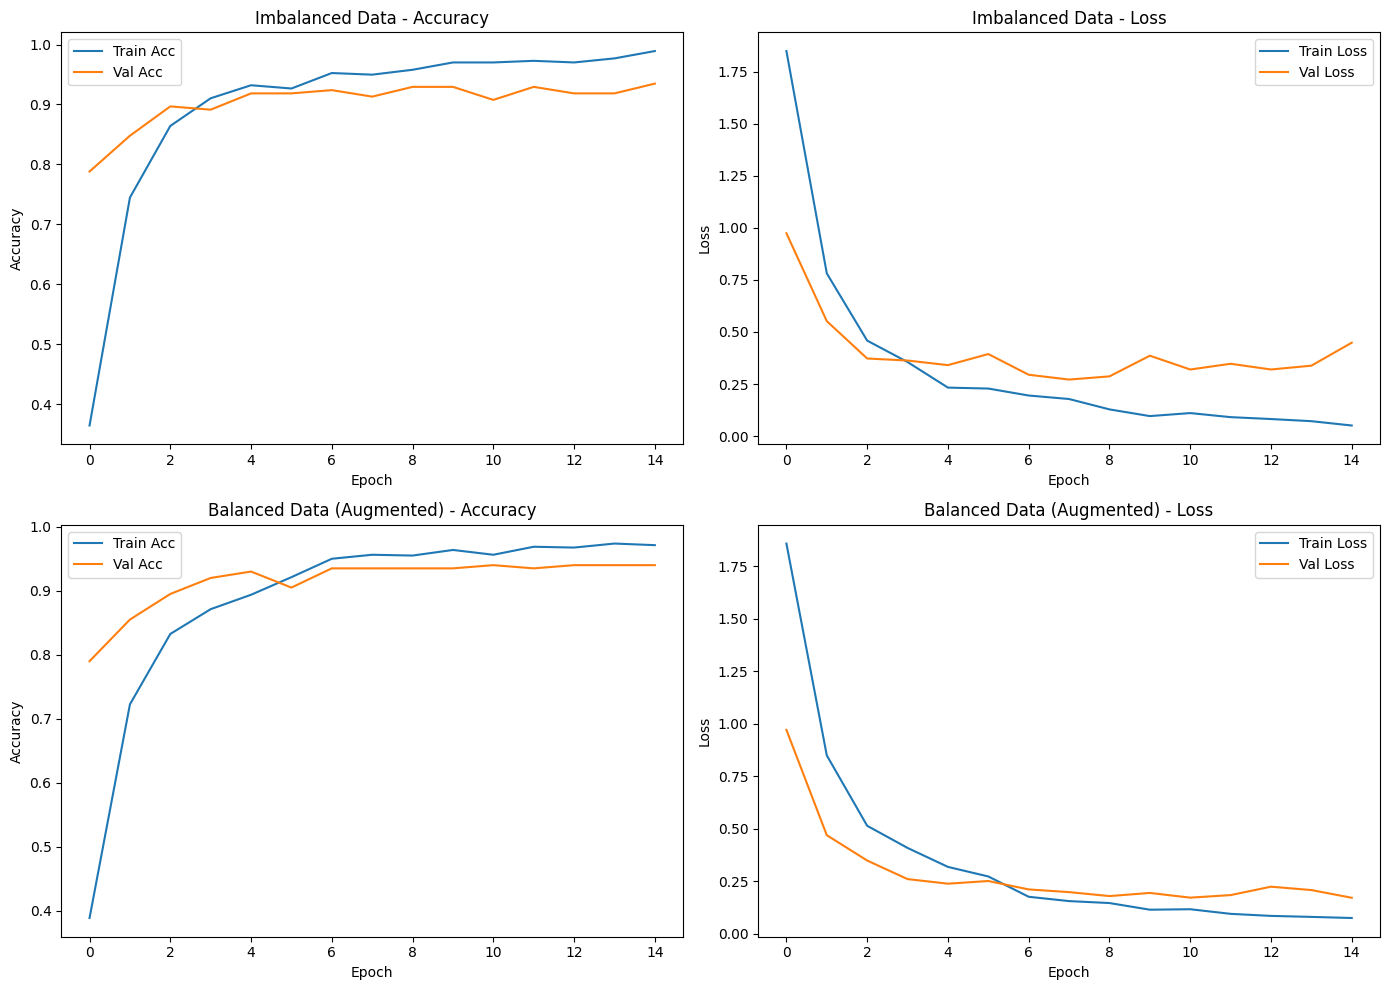

In [89]:
import tensorflow as tf
from tensorflow.keras import layers, models

def create_model():
    """Defines a simple CNN for MNIST digit classification."""
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# ----- Create an IMBALANCED subset -----
# Take first 100 samples per class, but only 20 for class '8' (simulating imbalance)
imbalanced_indices = []
for digit in range(10):
    digit_indices = np.where(y_train_img == digit)[0]
    if digit == 8:
        imbalanced_indices.extend(digit_indices[:20])   # minority class
    else:
        imbalanced_indices.extend(digit_indices[:100])

imbalanced_indices = np.array(imbalanced_indices)
np.random.shuffle(imbalanced_indices)

X_imbalanced = X_train_img[imbalanced_indices]
y_imbalanced = y_train_img[imbalanced_indices]

print(f"Imbalanced dataset size: {len(X_imbalanced)}")
print(f"Class 8 count: {np.sum(y_imbalanced == 8)}")

# ----- Train model on IMBALANCED data -----
model_imbalanced = create_model()
history_imbalanced = model_imbalanced.fit(
    X_imbalanced, y_imbalanced,
    validation_split=0.2,
    epochs=15,
    batch_size=16,
    verbose=0
)
print("Finished training on imbalanced data.")

# ----- Create BALANCED data using augmentation for class '8' -----
X_class8_balanced, y_class8_balanced = augment_minority_class(
    X_imbalanced, y_imbalanced, target_class=8, num_samples=100
)

# Combine class 8's balanced data with the rest of the imbalanced classes
non_class8_mask = y_imbalanced != 8
X_rest = X_imbalanced[non_class8_mask]
y_rest = y_imbalanced[non_class8_mask]

X_balanced_full = np.concatenate([X_rest, X_class8_balanced], axis=0)
y_balanced_full = np.concatenate([y_rest, y_class8_balanced], axis=0)

# Shuffle the balanced dataset
shuffle_idx = np.random.permutation(len(X_balanced_full))
X_balanced_full = X_balanced_full[shuffle_idx]
y_balanced_full = y_balanced_full[shuffle_idx]

print(f"Balanced dataset size: {len(X_balanced_full)}")
print(f"Class 8 count: {np.sum(y_balanced_full == 8)}")

# ----- Train model on BALANCED data -----
model_balanced = create_model()
history_balanced = model_balanced.fit(
    X_balanced_full, y_balanced_full,
    validation_split=0.2,
    epochs=15,
    batch_size=16,
    verbose=0
)
print("Finished training on balanced data.")

# ----- Plot training/validation accuracy and loss side by side -----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Imbalanced - Accuracy
axes[0, 0].plot(history_imbalanced.history['accuracy'], label='Train Acc')
axes[0, 0].plot(history_imbalanced.history['val_accuracy'], label='Val Acc')
axes[0, 0].set_title('Imbalanced Data - Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()

# Imbalanced - Loss
axes[0, 1].plot(history_imbalanced.history['loss'], label='Train Loss')
axes[0, 1].plot(history_imbalanced.history['val_loss'], label='Val Loss')
axes[0, 1].set_title('Imbalanced Data - Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()

# Balanced - Accuracy
axes[1, 0].plot(history_balanced.history['accuracy'], label='Train Acc')
axes[1, 0].plot(history_balanced.history['val_accuracy'], label='Val Acc')
axes[1, 0].set_title('Balanced Data (Augmented) - Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()

# Balanced - Loss
axes[1, 1].plot(history_balanced.history['loss'], label='Train Loss')
axes[1, 1].plot(history_balanced.history['val_loss'], label='Val Loss')
axes[1, 1].set_title('Balanced Data (Augmented) - Loss')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()

plt.tight_layout()
plt.show()